# Credit Card Fraud Detection - Data Cleaning & Preprocessing

## Nama: [ISI NAMA]
## NIM: [ISI NIM]
## Mata Kuliah: Introduction to Data Science
## Week 5 Assignment

## 1. Pengumpulan Data

### Sumber Data
Dataset yang digunakan adalah Credit Card Fraud Detection dari Kaggle (Public Dataset).

### Alasan Pemilihan
Dataset ini dipilih karena:
- Relevan dengan kasus nyata (deteksi fraud)
- Banyak digunakan dalam penelitian data science
- Cocok untuk analisis preprocessing

### Eksplorasi Awal Dataset


In [15]:
import pandas as pd

# Load dataset
df = pd.read_csv('creditcard.csv')

# Struktur data
print("Shape:", df.shape)

# Info data
df.info()


Shape: (284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V

In [16]:
# Cek missing values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [17]:
# Missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)
print("\nTotal Missing:", missing_values.sum())

# Duplikasi
duplicate_count = df.duplicated().sum()
print("\nJumlah Duplikasi:", duplicate_count)

Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total Missing: 0



Jumlah Duplikasi: 1081


In [18]:
# Hapus duplikasi
print("Sebelum:", df.shape)
df = df.drop_duplicates()
print("Sesudah:", df.shape)

Sebelum: (284807, 31)
Sesudah: (283726, 31)


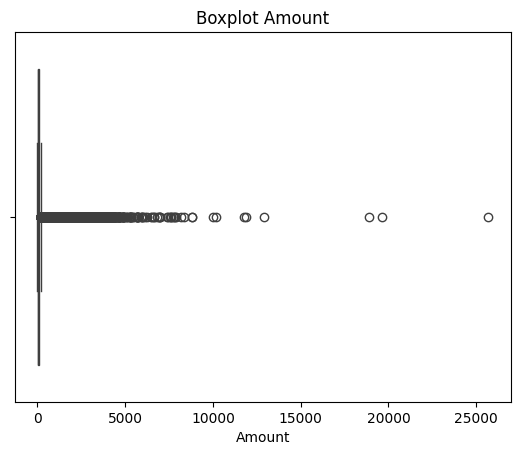

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Amount'])
plt.title("Boxplot Amount")
plt.show()

In [20]:
# Hitung Q1, Q3, IQR
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

# Filter outlier
df = df[(df['Amount'] >= (Q1 - 1.5 * IQR)) & 
        (df['Amount'] <= (Q3 + 1.5 * IQR))]

print("Data setelah hapus outlier:", df.shape)

Data setelah hapus outlier: (252041, 31)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

df = df.drop(['Amount', 'Time'], axis=1)

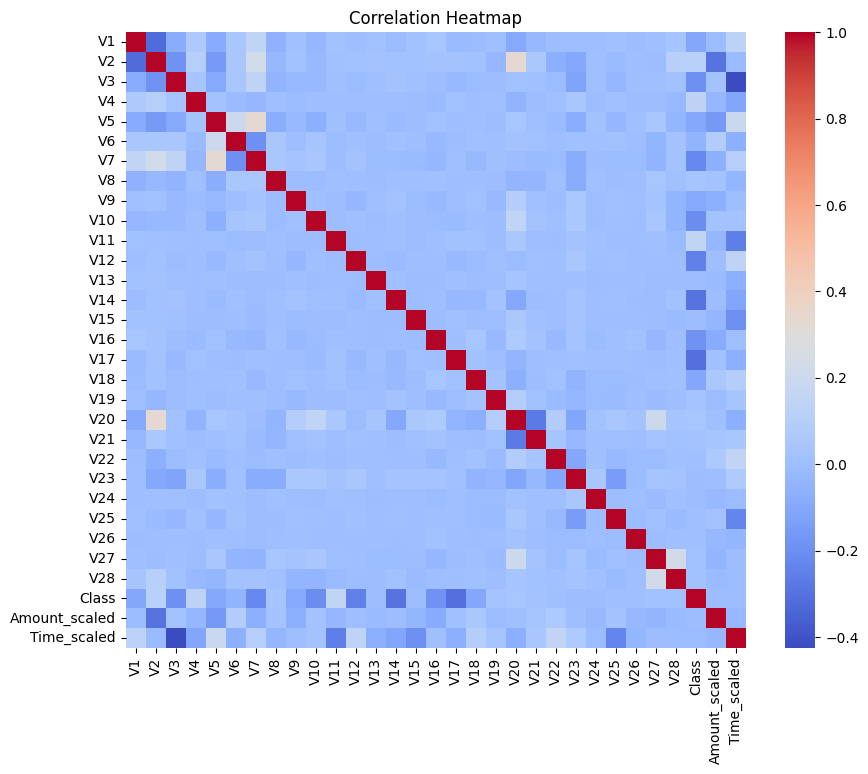

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

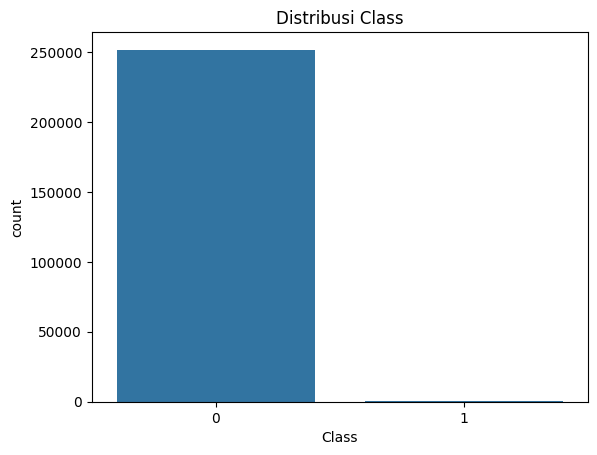

In [23]:
sns.countplot(x='Class', data=df)
plt.title("Distribusi Class")
plt.show()

Dataset menunjukkan ketidakseimbangan kelas (imbalanced), dimana data fraud jauh lebih sedikit dibanding non-fraud.